## Homework 7

In [68]:
# --- Загальні імпорти ---
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import zipfile
from urllib.request import urlretrieve

# --- Імпорти NLTK ---
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# --- Імпорти Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Одноразове завантаження ресурсів NLTK ---
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4') # Потрібно для WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elija\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\elija\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\elija\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\elija\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### 1. Завантаження даних

In [69]:
dataset_url = "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/main/SpamEmailClassificationDataset.zip"
zip_file_path = "spam_dataset.zip"
download_path = "./spam-data/"

if not os.path.exists(download_path):
    print("Завантаження датасету...")
    try:
        urlretrieve(dataset_url, zip_file_path)
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(download_path)
        os.remove(zip_file_path)
        print("Датасет завантажено та розархівовано.")
    except Exception as e:
        print(f"Помилка при завантаженні: {e}")
else:
    print("Датасет вже завантажено.")



Датасет вже завантажено.


In [70]:
# Read CSV file ... combined_data.csv
df_file_path = os.path.join(download_path, "SpamEmailClassificationDataset", "combined_data.csv")
if os.path.exists(df_file_path):
    data = pd.read_csv(df_file_path, skiprows=1)
    data.columns = ['label', 'text'] 
    # 1 = spam, 0 = ham
    print(data.head())
    print("\nРозподіл класів у повному датасеті:")
    print(data['label'].value_counts())

   label                                               text
0      1  ounce feather bowl hummingbird opec moment ala...
1      1  wulvob get your medircations online qnb ikud v...
2      0   computer connection from cnn com wednesday es...
3      1  university degree obtain a prosperous future m...
4      0  thanks for all your answers guys i know i shou...

Розподіл класів у повному датасеті:
label
1    7813
0    7047
Name: count, dtype: int64


### 2. Вибірка та візуалізація


Створено фінальний датасет з 3000 повідомлень.
   label                                               text
0      0  dave will continue to have the friday afternoo...
1      1  need in software for your pc ? just visit our ...
2      0  on escapenumber escapenumber escapenumber arne...
3      1  if this is your wife then it is already too la...
4      0  hello everyone i want to calculate an instrume...


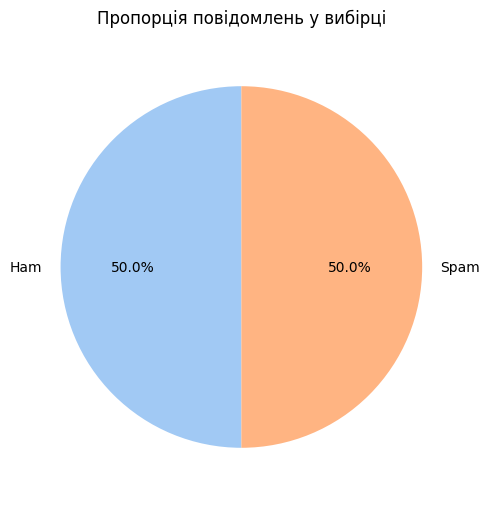

In [71]:
if not data.empty:
    # Робимо випадкову вибірку
    df_spam = data[data['label'] == 1]
    df_ham = data[data['label'] == 0]

    sample_size = 1500
    df_spam_sample = df_spam.sample(n=sample_size, random_state=42)
    df_ham_sample = df_ham.sample(n=sample_size, random_state=42)
    df = pd.concat([df_spam_sample, df_ham_sample])

    # Перемішування рядків у DataFrame
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"\nСтворено фінальний датасет з {len(df)} повідомлень.")
    print(df.head())

    # Візуалізація розподілу класів
    labels = ['Ham', 'Spam']
    sizes = df['label'].value_counts().sort_index()
    colors = ['#a1c9f4', '#ffb482']

    plt.figure(figsize=(5, 5))
    plt.pie(sizes, labels=labels, colors=colors, startangle=90, autopct='%1.1f%%')
    plt.axis('equal')
    plt.tight_layout()
    plt.title('Пропорція повідомлень у вибірці')
    plt.show()

else:
    print("Датафрейм порожній.")

### 3. Попередня обробка тексту

In [72]:
if not df.empty:
    corpus = []
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words("english"))

    print("\nПочаток обробки тексту...")
    for document in df["text"]:
        document = re.sub("[^a-zA-Z]", " ", str(document)).lower()
        document = document.split()
        document = [lemmatizer.lemmatize(word) for word in document if word not in stop_words]
        # print(document)
        document = list(set(document))
        document = " ".join(document)
        corpus.append(document)

    df["processed_text"] = corpus

    print("Обробка завершена.")
    print(df.head())

else:
    print("Датафрейм порожній.")


Початок обробки тексту...
Обробка завершена.
   label                                               text  \
0      0  dave will continue to have the friday afternoo...   
1      1  need in software for your pc ? just visit our ...   
2      0  on escapenumber escapenumber escapenumber arne...   
3      1  if this is your wife then it is already too la...   
4      0  hello everyone i want to calculate an instrume...   

                                      processed_text  
0  call question conflict remains effective pm ar...  
1  pc might visit best shery site regard need sof...  
2  deltaconfig tried object give smooth additiona...  
3  solely without big com woman message contains ...  
4  st code mannheim rger deal method problem opti...  


### 4. Підготовка структур даних

In [73]:
if not df.empty:
    # Розділяємо дані на тренувальні та тестові (80% train, 20% test)
    # Використовуємо stratify для збереження балансу класів
    train_df, test_df = train_test_split(df, 
                                         test_size=0.2, 
                                         random_state=42, 
                                         stratify=df['label'])

    train_spam = train_df[train_df['label'] == 1]['processed_text'].tolist()

    train_ham = train_df[train_df['label'] == 0]['processed_text'].tolist()

    # список для оцінки
    test_spam_messages = test_df[test_df['label'] == 1]['processed_text'].tolist()
    test_ham_messages = test_df[test_df['label'] == 0]['processed_text'].tolist()
    
    test_emails = {
        'spam': test_spam_messages,
        'ham': test_ham_messages
    }
    y_true_test = [1] * len(test_spam_messages) + [0] * len(test_ham_messages)
    X_test = test_spam_messages + test_ham_messages

    print(f"Дані підготовлено:")
    print(f"Тренувальних 'spam': {len(train_spam)}")
    print(f"Тренувальних 'ham': {len(train_ham)}")
    print(f"Тестових 'spam': {len(test_emails['spam'])}")
    print(f"Тестових 'ham': {len(test_emails['ham'])}")

else:
    print("Датафрейм порожній.")

Дані підготовлено:
Тренувальних 'spam': 1200
Тренувальних 'ham': 1200
Тестових 'spam': 300
Тестових 'ham': 300


### 5. Реалізація Наївного Баєса

In [74]:
# --- 5. Реалізація Наївного Баєса ---

# 1. Створюємо словник унікальних слів зі СПАМ-листів (з train_spam)
vocab_words_spam = []
for sentence in train_spam: # Використовуємо train_spam з комірки [51]
    sentence_as_list = sentence.split()
    for word in sentence_as_list:
        vocab_words_spam.append(word)

vocab_unique_words_spam = list(set(vocab_words_spam))

# 2. Розраховуємо "spamicity" (P(Word|Spam))
dict_spamicity = {}
total_spam = len(train_spam)
alpha = 1 # Параметр згладжування Лапласа

for w in vocab_unique_words_spam:
    emails_with_w = 0
    for sentence in train_spam:
        if w in sentence.split(): 
            emails_with_w += 1
    spamicity = (emails_with_w + alpha) / (total_spam + alpha * 2) 
    dict_spamicity[w] = spamicity

print(f"Розраховано 'spamicity' для {len(vocab_unique_words_spam)} унікальних слів зі спаму.")

# 3. Створюємо словник унікальних слів з НЕ-СПАМ-листів (з train_ham)
vocab_words_ham = []
for sentence in train_ham:
    sentence_as_list = sentence.split()
    for word in sentence_as_list:
        vocab_words_ham.append(word)

vocab_unique_words_ham = list(set(vocab_words_ham))

# 4. Розраховуємо "hamicity" (P(Word|Ham))
dict_hamicity = {}
total_ham = len(train_ham)

for w in vocab_unique_words_ham:
    emails_with_w = 0
    for sentence in train_ham:
        if w in sentence.split():
            emails_with_w += 1
    hamicity = (emails_with_w + alpha) / (total_ham + alpha * 2)
    dict_hamicity[w] = hamicity

print(f"Розраховано 'hamicity' для {len(vocab_unique_words_ham)} унікальних слів з не-спаму.")

# 5. Розраховуємо апріорні ймовірності P(Spam) та P(Ham)
total_emails = total_spam + total_ham
prob_spam = total_spam / total_emails
prob_ham = total_ham / total_emails

print(f"\nАпріорна ймовірність Спаму (P(Spam)): {prob_spam:.4f}")
print(f"Апріорна ймовірність Не-спаму (P(Ham)): {prob_ham:.4f}")

# 6. Визначаємо ймовірності для невідомих слів
# P(Unknown|Spam)
spam_prob_unknown = alpha / (total_spam + alpha * 2)
# P(Unknown|Ham)
ham_prob_unknown = alpha / (total_ham + alpha * 2)

# 7. Функція множення
def mult(list_):
    total_prob = 1
    for i in list_:
         total_prob = total_prob * i
    return total_prob

# 8. Функція класифікатора
# Вона приймає список слів
def bayes_classify(email_words_list):
    probs_s = [] # Список P(Word_i|Spam)
    probs_h = [] # Список P(Word_i|Ham)
    
    for word in email_words_list:
        # Ймовірність P(Word|Spam)
        pr_WS = dict_spamicity.get(word, spam_prob_unknown)
        
        # Ймовірність P(Word|Ham)
        pr_WH = dict_hamicity.get(word, ham_prob_unknown)

        probs_s.append(pr_WS)
        probs_h.append(pr_WH)

    # Розраховуємо P(Spam) * P(Email|Spam)
    # P(Spam) * P(W1|Spam) * P(W2|Spam) * ...
    prob_s_given_email = prob_spam * mult(probs_s)
    
    # Розраховуємо P(Ham) * P(Email|Ham)
    # P(Ham) * P(W1|Ham) * P(W2|Ham) * ...
    prob_h_given_email = prob_ham * mult(probs_h)

    # Нормалізуємо, щоб отримати P(Spam|Email)
    denominator = prob_s_given_email + prob_h_given_email
    
    # Уникаємо ділення на нуль
    if denominator == 0:
        return 0
        
    final_classification_prob = prob_s_given_email / denominator
    
    if final_classification_prob >= 0.5:
        return 1 # Спам
    else:
        return 0 # Не спам

print("\nФункції 'mult' та 'bayes_classify' готові до використання.")

Розраховано 'spamicity' для 24056 унікальних слів зі спаму.
Розраховано 'hamicity' для 20404 унікальних слів з не-спаму.

Апріорна ймовірність Спаму (P(Spam)): 0.5000
Апріорна ймовірність Не-спаму (P(Ham)): 0.5000

Функції 'mult' та 'bayes_classify' готові до використання.


### 6. Аналіз якості класифікатора

Отримано 600 прогнозів для тестового набору.


,precision,recall,f1-score,support
Ham (0),0.780,0.990,0.872,300.000
Spam (1),0.986,0.720,0.832,300.000
accuracy,0.855,0.855,0.855,0.855
macro avg,0.883,0.855,0.852,600.000
weighted avg,0.883,0.855,0.852,600.000


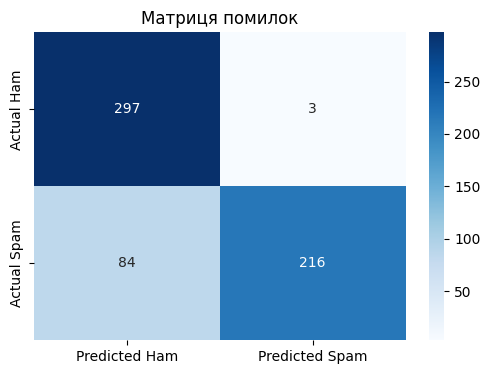

In [75]:
# 1. Перевіряємо класифікатор на тестовому наборі
y_pred_test = []

for processed_email_str in X_test:
    email_words = processed_email_str.split()
    prediction = bayes_classify(email_words)
    y_pred_test.append(prediction)

print(f"Отримано {len(y_pred_test)} прогнозів для тестового набору.")

# 2. Будуємо звіт про класифікацію
report = classification_report(y_true_test, y_pred_test, output_dict=True, target_names=['Ham (0)', 'Spam (1)'])
report_df = pd.DataFrame(report).transpose()
display(report_df.round(3))

cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Ham', 'Predicted Spam'], 
                yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Матриця помилок')
plt.show()

In [76]:
# 3. Слова з найбільшою ймовірністю зустрітися у спамі (P(Word|Spam))
print("--- Топ 20 Найбільш \"спамних\" слів (за P(Word|Spam)) ---")

sorted_spamicity = sorted(dict_spamicity.items(), key=lambda item: item[1], reverse=True)

for word, probability in sorted_spamicity[:20]:
    print(f"{word}: {probability:.4f}")

--- Топ 20 Найбільш "спамних" слів (за P(Word|Spam)) ---
escapenumber: 0.4676
http: 0.3952
com: 0.2912
one: 0.2604
price: 0.2596
u: 0.2529
day: 0.2188
time: 0.2138
please: 0.1889
get: 0.1805
like: 0.1772
new: 0.1755
escapelong: 0.1747
offer: 0.1705
www: 0.1664
best: 0.1606
may: 0.1597
see: 0.1597
e: 0.1547
email: 0.1539
